## Objective

The objective of this survival analysis is to estimate the **time until loan default** based on borrower and loan characteristics available at the time of loan origination. Unlike the preceding classification analysis, which predicts whether a borrower is likely to default, survival analysis incorporates the time dimension to determine **how long a loan is expected to remain active before a default event occurs**.

The analysis aims to:

- Estimate the survival probability of loans over time.
- Model the relationship between borrower and loan characteristics and the time to default.
- Identify factors that accelerate or delay loan default using survival models.
- Account for censored observations, including loans that are fully paid or remain active without default during the observation period.

To ensure that the model reflects a real-world lending scenario, only information available at or before loan issuance is used as predictor variables. Variables containing post-loan information or outcome-related information are excluded to prevent data leakage and ensure that predictions are based solely on information available when the lending decision is made.

In [191]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 


In [192]:
df = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\Datasets\Cleaned_lending_club_2007_2014.csv').iloc[:,1:]

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           465687 non-null  int64  
 1   member_id                    465687 non-null  int64  
 2   loan_amnt                    465687 non-null  int64  
 3   funded_amnt                  465687 non-null  int64  
 4   funded_amnt_inv              465687 non-null  float64
 5   term                         465687 non-null  object 
 6   int_rate                     465687 non-null  float64
 7   installment                  465687 non-null  float64
 8   grade                        465687 non-null  object 
 9   sub_grade                    465687 non-null  object 
 10  emp_title                    465687 non-null  object 
 11  emp_length                   465687 non-null  object 
 12  home_ownership               465687 non-null  object 
 13 

In [194]:
# ------------------------------------------------------------------
# Columns to remove (Identifiers / No predictive value)
# ------------------------------------------------------------------
id_cols = [
    'id',
    'member_id',
    '19'
]

# ------------------------------------------------------------------
# Columns used only to construct the survival dataset
# (Drop after creating 'duration' and 'event')
# ------------------------------------------------------------------
survival_cols = [
    'issue_d',
    'last_pymnt_d',
    'loan_status'
]

# ------------------------------------------------------------------
# Columns to remove (Post-loan information / Data leakage)
# ------------------------------------------------------------------
leakage_cols = [
    'next_pymnt_d',
    'last_credit_pull_d',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt'
]

# ------------------------------------------------------------------
# Columns to remove (High-cardinality / Free-text)
# ------------------------------------------------------------------
text_cols = [
    'emp_title',
    'title',
    'zip_code'
]

# ------------------------------------------------------------------
# Optional columns to remove (Potentially redundant)
# ------------------------------------------------------------------
optional_cols = [
    'funded_amnt',
    'funded_amnt_inv'
]

# ------------------------------------------------------------------
# Final list of columns to drop before fitting the Cox model
# (Keep issue_d, last_pymnt_d, and loan_status until duration and
# event have been created.)
# ------------------------------------------------------------------
drop_cols = (
    id_cols +
    leakage_cols +
    text_cols +
    optional_cols
)

In [195]:
df = df.drop(drop_cols,axis=1)

In [196]:
df['last_pymnt_d']

0         Jan-15
1         Apr-13
2         Jun-14
3         Jan-15
4         Jan-16
           ...  
465682    Jan-16
465683    Dec-14
465684    Jan-16
465685    Dec-14
465686    Jan-16
Name: last_pymnt_d, Length: 465687, dtype: object

In [197]:
df['last_pymnt_d'] = pd.to_datetime('01-'+df['last_pymnt_d'])
df['issue_d'] = pd.to_datetime('01-'+df['issue_d'])

C:\Users\Dev\AppData\Local\Temp\ipykernel_13356\3430525759.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_pymnt_d'] = pd.to_datetime('01-'+df['last_pymnt_d'])
C:\Users\Dev\AppData\Local\Temp\ipykernel_13356\3430525759.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime('01-'+df['issue_d'])


In [198]:
df['Survival_Time'] = df['last_pymnt_d'] - df['issue_d']

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype          
---  ------                       --------------   -----          
 0   loan_amnt                    465687 non-null  int64          
 1   term                         465687 non-null  object         
 2   int_rate                     465687 non-null  float64        
 3   installment                  465687 non-null  float64        
 4   grade                        465687 non-null  object         
 5   sub_grade                    465687 non-null  object         
 6   emp_length                   465687 non-null  object         
 7   home_ownership               465687 non-null  object         
 8   annual_inc                   465687 non-null  float64        
 9   verification_status          465687 non-null  object         
 10  issue_d                      465687 non-null  datetime64[ns] 
 11  loan_status  

In [200]:
df = df.drop(['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'],axis = 1)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype          
---  ------                       --------------   -----          
 0   loan_amnt                    465687 non-null  int64          
 1   term                         465687 non-null  object         
 2   int_rate                     465687 non-null  float64        
 3   installment                  465687 non-null  float64        
 4   grade                        465687 non-null  object         
 5   sub_grade                    465687 non-null  object         
 6   emp_length                   465687 non-null  object         
 7   home_ownership               465687 non-null  object         
 8   annual_inc                   465687 non-null  float64        
 9   verification_status          465687 non-null  object         
 10  issue_d                      465687 non-null  datetime64[ns] 
 11  loan_status  

In [202]:
# Renaming survival time to duration
df = df.rename(columns={'Survival_Time': "Duration"})

# Creating an event column where defaulter and charged off are taken as one and all other are zero
df.loan_status.value_counts()

# Non-default loan statuses
non_default = [
    "Current",
    "Fully Paid",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Does not meet the credit policy. Status:Fully Paid"
]

# Default loan statuses
default = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

# Creating a column called event which is a binary column and 1 represents the customer is defaulted zero represent the customer is either non defaulted or fully paid 
df.loc[df[df.loan_status.isin(default)].index,'Event'] = 1

df.loc[df[df.loan_status.isin(non_default)].index,'Event'] = 0

# Filling the missingness

In [203]:
df.info()
df = df.drop('earliest_cr_line',axis = 1)
df['mths_since_last_major_derog']  = df['mths_since_last_major_derog'].fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype          
---  ------                       --------------   -----          
 0   loan_amnt                    465687 non-null  int64          
 1   term                         465687 non-null  object         
 2   int_rate                     465687 non-null  float64        
 3   installment                  465687 non-null  float64        
 4   grade                        465687 non-null  object         
 5   sub_grade                    465687 non-null  object         
 6   emp_length                   465687 non-null  object         
 7   home_ownership               465687 non-null  object         
 8   annual_inc                   465687 non-null  float64        
 9   verification_status          465687 non-null  object         
 10  issue_d                      465687 non-null  datetime64[ns] 
 11  loan_status  

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,acc_now_delinq,Event
loan_amnt,1.000000,0.167354,0.949639,0.370721,0.057246,0.006993,-0.020299,-0.028741,-0.100900,0.203879,-0.081221,0.331442,0.118411,0.235054,-0.008154,-0.052186,NaN,0.006190,0.006069
int_rate,0.167354,1.000000,0.148873,-0.046073,0.159710,0.079190,0.205629,0.069354,0.063055,0.012368,0.066670,-0.004540,0.322427,-0.032900,0.020299,0.087592,NaN,0.030325,0.158570
installment,0.949639,0.148873,1.000000,0.367985,0.049853,0.017154,0.002248,-0.019017,-0.091760,0.196564,-0.070175,0.320233,0.137442,0.215707,-0.006119,-0.040474,NaN,0.008828,0.008696
annual_inc,0.370721,-0.046073,0.367985,1.000000,-0.188627,0.058842,0.056785,0.018152,-0.051629,0.157639,-0.015566,0.332256,0.037736,0.224567,-0.000554,0.004002,NaN,0.017030,-0.049119
dti,0.057246,0.159710,0.049853,-0.188627,1.000000,-0.003667,-0.012407,-0.011414,-0.036578,0.303864,-0.046276,0.143316,0.200696,0.228165,0.000440,-0.010791,NaN,0.009573,0.039816
delinq_2yrs,0.006993,0.079190,0.017154,0.058842,-0.003667,1.000000,0.018062,-0.060234,-0.028012,0.059126,-0.010895,-0.031105,-0.012991,0.130801,0.039218,0.061844,NaN,0.126630,-0.004957
inq_last_6mths,-0.020299,0.205629,0.002248,0.056785,-0.012407,0.018062,1.000000,0.033201,0.032003,0.092917,0.038373,-0.015626,-0.094246,0.124253,-0.001895,0.043737,NaN,-0.006886,0.073949
mths_since_last_delinq,-0.028741,0.069354,-0.019017,0.018152,-0.011414,-0.060234,0.033201,1.000000,0.032496,0.022592,0.067393,-0.066075,0.003423,0.115286,0.016864,0.500027,NaN,-0.038399,-0.007655
mths_since_last_record,-0.100900,0.063055,-0.091760,-0.051629,-0.036578,-0.028012,0.032003,0.032496,1.000000,-0.037064,0.689623,-0.113839,-0.052034,-0.022715,0.013918,0.061880,NaN,-0.002800,-0.004105
open_acc,0.203879,0.012368,0.196564,0.157639,0.303864,0.059126,0.092917,0.022592,-0.037064,1.000000,-0.030615,0.222878,-0.122473,0.681996,0.011792,0.010449,NaN,0.018172,-0.011203


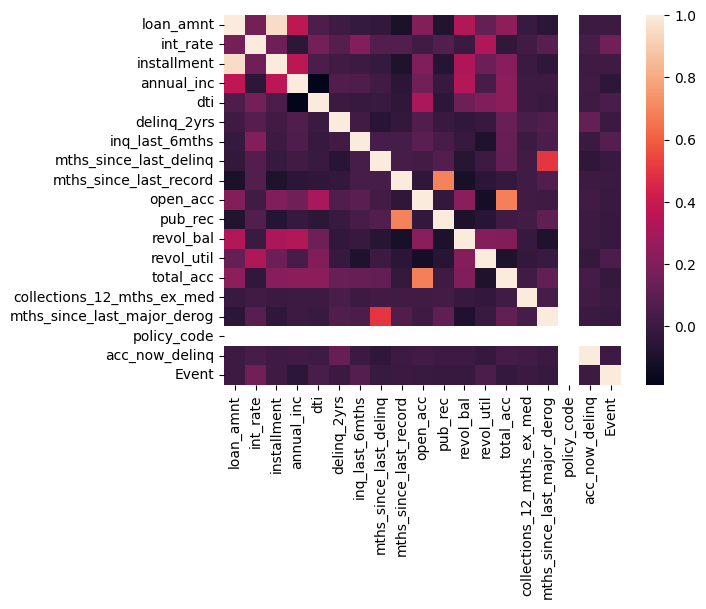

In [204]:
sns.heatmap(df.corr(numeric_only=True))
df.corr(numeric_only=True)

In [205]:
# one is highly correlated with loan amount - 0.94 and one is constant 
df = df.drop(['installment','policy_code'],axis = 1)

In [206]:
df = df.drop('addr_state', axis = 1)

In [207]:
df = df.drop('collections_12_mths_ex_med', axis =1 )

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype          
---  ------                       --------------   -----          
 0   loan_amnt                    465687 non-null  int64          
 1   term                         465687 non-null  object         
 2   int_rate                     465687 non-null  float64        
 3   grade                        465687 non-null  object         
 4   sub_grade                    465687 non-null  object         
 5   emp_length                   465687 non-null  object         
 6   home_ownership               465687 non-null  object         
 7   annual_inc                   465687 non-null  float64        
 8   verification_status          465687 non-null  object         
 9   issue_d                      465687 non-null  datetime64[ns] 
 10  loan_status                  465687 non-null  object         
 11  pymnt_plan   

In [209]:
# Droping date date columns 
df = df.drop(['issue_d','last_pymnt_d'],axis =1 )

In [210]:
# Converting duration in days to floats days 
df['Duration'] = df['Duration'].astype(str).str.split().str[0].astype(float)

In [211]:
# now converting into months- assuming 30 days in a month
df['Duration'] = np.round(df['Duration']/30,2)

In [212]:
df['Duration']

0         37.57
1         16.23
2         30.43
3         37.57
4         49.73
          ...  
465682    24.33
465683    11.13
465684    24.33
465685    11.13
465686    24.33
Name: Duration, Length: 465687, dtype: float64

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    465687 non-null  int64  
 1   term                         465687 non-null  object 
 2   int_rate                     465687 non-null  float64
 3   grade                        465687 non-null  object 
 4   sub_grade                    465687 non-null  object 
 5   emp_length                   465687 non-null  object 
 6   home_ownership               465687 non-null  object 
 7   annual_inc                   465687 non-null  float64
 8   verification_status          465687 non-null  object 
 9   loan_status                  465687 non-null  object 
 10  pymnt_plan                   465687 non-null  object 
 11  purpose                      465687 non-null  object 
 12  dti                          465687 non-null  float64
 13 

In [214]:
# dropping great features because if we know Sir great then it automatically means we know grade
df = df.drop('grade', axis =1 )

In [215]:
df = df.drop('loan_status', axis =1 )   # because we have event column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    465687 non-null  int64  
 1   term                         465687 non-null  object 
 2   int_rate                     465687 non-null  float64
 3   sub_grade                    465687 non-null  object 
 4   emp_length                   465687 non-null  object 
 5   home_ownership               465687 non-null  object 
 6   annual_inc                   465687 non-null  float64
 7   verification_status          465687 non-null  object 
 8   pymnt_plan                   465687 non-null  object 
 9   purpose                      465687 non-null  object 
 10  dti                          465687 non-null  float64
 11  delinq_2yrs                  465687 non-null  float64
 12  inq_last_6mths               465687 non-null  float64
 13 

In [216]:
# The original 'emp_length' variable showed a nearly flat default rate across categories,
# indicating limited predictive power. Therefore, it was simplified into a binary feature
# representing whether employment information is available or not. 
df['Employement'] = np.where(df['emp_length']=='UNKNOWN',0,1)
df =df.drop('emp_length',axis =1)

In [217]:
df['pymnt_plan'].value_counts()   # It is like a constant column 99.99% of the values are known and a few 9 are yes 

df = df.drop('pymnt_plan', axis =1 )

In [218]:
# df.info()
df['purpose'].value_counts()
purpose_mapping = {
    # Debt Management
    "debt_consolidation": "Debt_Management",
    "credit_card": "Debt_Management",

    # Personal Expenses
    "medical": "Personal",
    "moving": "Personal",
    "vacation": "Personal",
    "wedding": "Personal",
    "other": "Personal",

    # Asset & Home
    "home_improvement": "Asset_Home",
    "house": "Asset_Home",
    "car": "Asset_Home",

    # Business & Education
    "small_business": "Business_Education",
    "educational": "Business_Education",
    "renewable_energy": "Business_Education",

    # Major Purchases
    "major_purchase": "Major_Purchase"
}

df["purpose_group"] = df["purpose"].map(purpose_mapping)
df = df.drop('purpose', axis =1 )

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465687 entries, 0 to 465686
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    465687 non-null  int64  
 1   term                         465687 non-null  object 
 2   int_rate                     465687 non-null  float64
 3   sub_grade                    465687 non-null  object 
 4   home_ownership               465687 non-null  object 
 5   annual_inc                   465687 non-null  float64
 6   verification_status          465687 non-null  object 
 7   dti                          465687 non-null  float64
 8   delinq_2yrs                  465687 non-null  float64
 9   inq_last_6mths               465687 non-null  float64
 10  mths_since_last_delinq       465687 non-null  float64
 11  mths_since_last_record       465687 non-null  float64
 12  open_acc                     465687 non-null  float64
 13 

In [220]:
df['term'] = df['term'].str.strip()

In [221]:
target = ['Duration','Event']

In [222]:
home_ownership_mapping = {
    "MORTGAGE": "MORTGAGE",
    "RENT": "RENT",
    "OWN": "OWN",
    "OTHER": "OTHER",
    "NONE": "OTHER",
    "ANY": "OTHER"
}
df["home_ownership"] = df["home_ownership"].replace(home_ownership_mapping)

In [223]:
df = df[df["Duration"] >= 0]
df = df.drop('application_type', axis =1)  # it is a coonstant column 

# kaplan meier estimated survival analysis
- Full data survival analysis


## Log-Rank Test

The **Log-Rank Test** is a non-parametric statistical test used to compare the survival distributions of **two or more independent groups**. It evaluates whether there is a statistically significant difference between the Kaplan–Meier survival curves over the entire follow-up period.

### Hypotheses

- **Null Hypothesis ($H_0$):** The survival functions of the groups are identical (no difference in survival between the groups).

- **Alternative Hypothesis ($H_1$):** At least one group's survival function differs from the others.

### Decision Rule

- If **p-value < 0.05**, reject the null hypothesis and conclude that there is a statistically significant difference between the survival curves.
- If **p-value ≥ 0.05**, fail to reject the null hypothesis, indicating insufficient evidence of a difference in survival between the groups.



In [224]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
# Survival on whole data 

kmf= KaplanMeierFitter()

kmf.fit(durations=df['Duration'],
        event_observed = df['Event'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 465681 total observations, 422018 right-censored observations>

inf


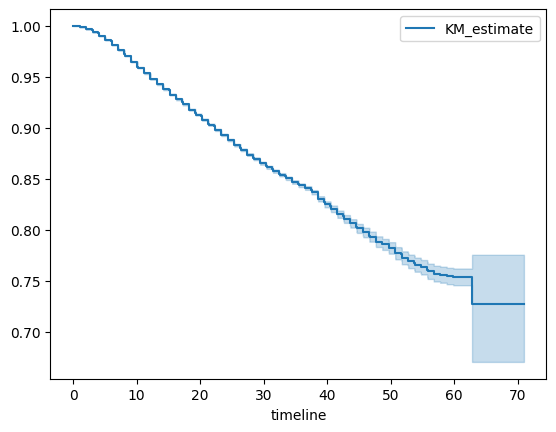

In [225]:
kmf.plot_survival_function()
print(kmf.median_survival_time_)

### Interpretation

- The Kaplan–Meier survival curve shows the estimated probability that a loan **has not experienced the event (default/charge-off)** over time.
- At the beginning of the observation period, the survival probability is **1.0 (100%)**, indicating that no events have occurred.
- The survival probability gradually decreases over time as more loans experience the event.
- By the end of the follow-up period (approximately **70 months**), the estimated survival probability is around **0.73**, suggesting that nearly **73% of loans remain event-free**, while approximately **27% have experienced the event**.
- The shaded region represents the **95% confidence interval** of the survival estimate. It widens toward the end of the timeline because fewer loans remain under observation, resulting in greater uncertainty.
- The reported **median survival time is `inf` (infinity)** because the survival probability never falls below **50%** during the study period. Therefore, fewer than half of the loans experienced the event, and the median survival time cannot be estimated from the available follow-up.


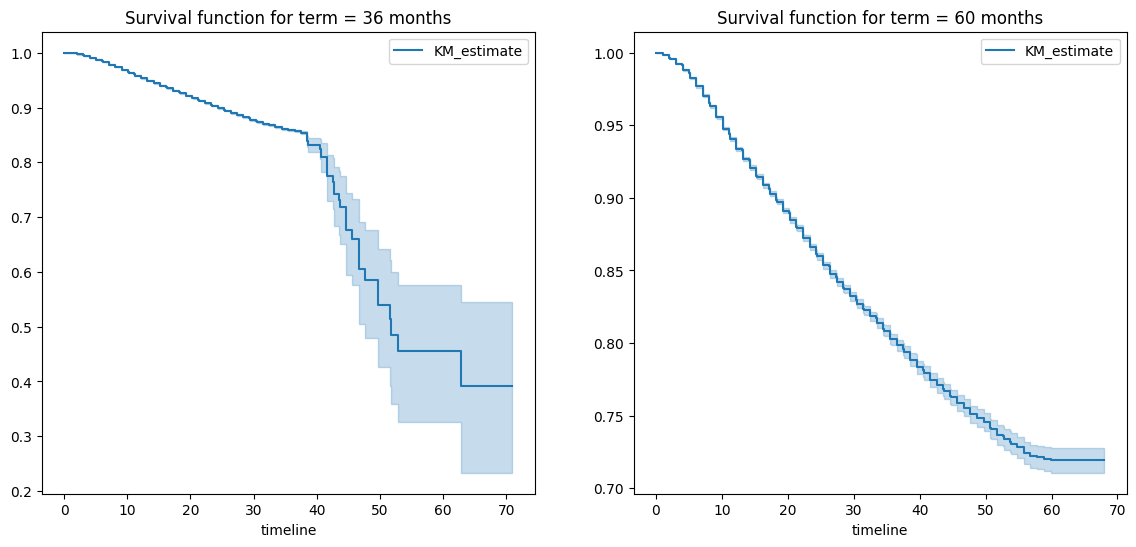

In [226]:
# Survival curves categroy - term
df.term.unique()

plt.figure(figsize=(14,6))
for j,i in enumerate(df.term.unique()):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['term'] == i],
        event_observed = df['Event'][df['term'] == i])

    plt.subplot(1,2,j+1)
    plt.title(f'Survival function for term = {i}')
    plt.xlabel('Months')
    kmf.plot_survival_function()

result = logrank_test(
    durations_A= df['Duration'][df['term'] == df.term.unique()[0]],
    durations_B= df['Duration'][df['term'] == df.term.unique()[1]],
    event_observed_A= df['Event'][df['term'] == df.term.unique()[0]],
    event_observed_B= df['Event'][df['term'] == df.term.unique()[1]]
)
result.print_summary()


### Interpretation

- The Kaplan–Meier survival curves compare the probability of remaining **event-free (not defaulted/charged off)** for loans with **36-month** and **60-month** terms.
- The survival probability for **60-month loans** decreases more rapidly than for **36-month loans**, indicating that borrowers with longer loan terms experience the event sooner and more frequently.
- The **36-month** loans maintain a higher survival probability throughout most of the follow-up period, suggesting a lower default risk.
- The wider confidence interval near the end of the **36-month** curve is due to fewer loans remaining under observation, which increases uncertainty in the survival estimates.
- The **Log-Rank test** produced a test statistic of **1202.52** with **p < 0.005**, indicating a statistically significant difference between the survival distributions of the two loan terms.
- Therefore, the null hypothesis that both groups have identical survival functions is **rejected**.
- These results suggest that **loan term is an important factor associated with the time to default**, with **60-month loans exhibiting poorer survival than 36-month loans**.


Reject H0: - There is significant difference between grade ['B1', 'B2', 'B3', 'B4', 'B5'] and ['A1', 'A2', 'A3', 'A4', 'A5']
Reject H0: - There is significant difference between grade ['C1', 'C2', 'C3', 'C4', 'C5'] and ['A1', 'A2', 'A3', 'A4', 'A5']
Reject H0: - There is significant difference between grade ['C1', 'C2', 'C3', 'C4', 'C5'] and ['B1', 'B2', 'B3', 'B4', 'B5']
Reject H0: - There is significant difference between grade ['D1', 'D2', 'D3', 'D4', 'D5'] and ['A1', 'A2', 'A3', 'A4', 'A5']
Reject H0: - There is significant difference between grade ['D1', 'D2', 'D3', 'D4', 'D5'] and ['B1', 'B2', 'B3', 'B4', 'B5']
Reject H0: - There is significant difference between grade ['D1', 'D2', 'D3', 'D4', 'D5'] and ['C1', 'C2', 'C3', 'C4', 'C5']
Reject H0: - There is significant difference between grade ['E1', 'E2', 'E3', 'E4', 'E5'] and ['A1', 'A2', 'A3', 'A4', 'A5']
Reject H0: - There is significant difference between grade ['E1', 'E2', 'E3', 'E4', 'E5'] and ['B1', 'B2', 'B3', 'B4', 'B5']


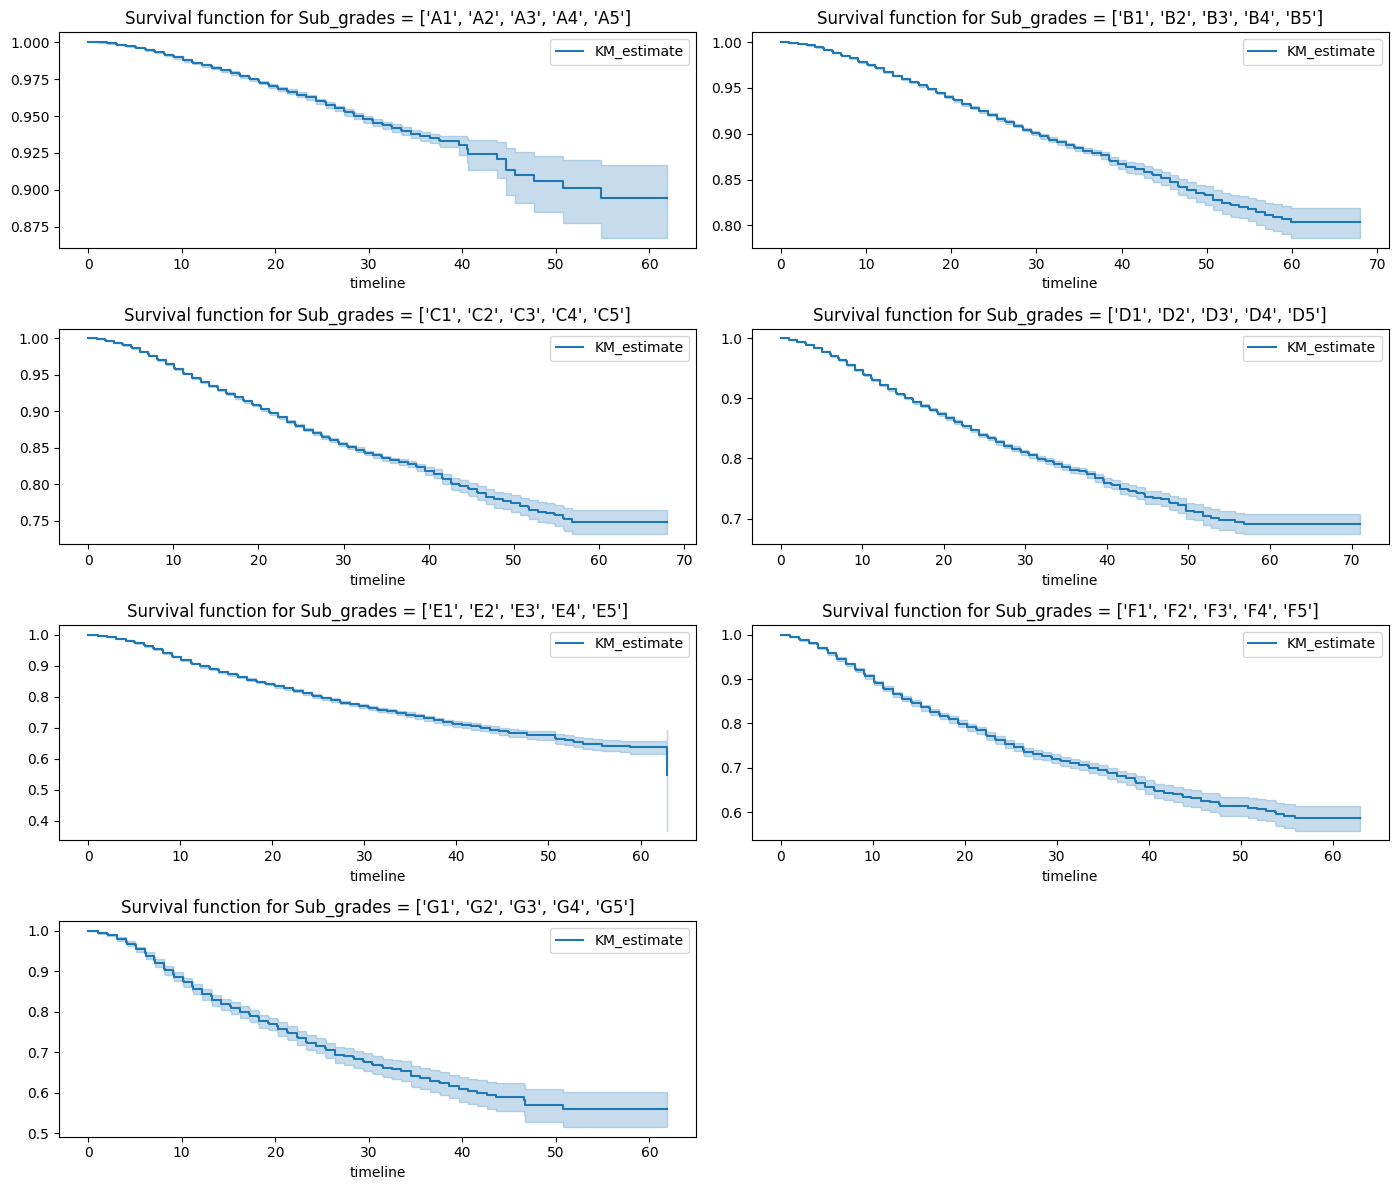

In [227]:
# Survival curves categroy - sub_grade
df.sub_grade.unique()
A = ['A1','A2','A3','A4','A5']
B = ['B1','B2','B3','B4','B5']
C = ['C1','C2','C3','C4','C5']
D = ['D1','D2','D3','D4','D5']
E = ['E1','E2','E3','E4','E5']
F = ['F1','F2','F3','F4','F5']
G = ['G1','G2','G3','G4','G5']

plt.figure(figsize=(14,12))
for j,i in enumerate([A,B,C,D,E,F,G]):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['sub_grade'].isin(i)],
        event_observed = df['Event'][df['sub_grade'].isin(i)])

    plt.subplot(4,2,j+1)
    plt.title(f'Survival function for Sub_grades = {i}')
    plt.xlabel('Months')
    kmf.plot_survival_function()
    plt.tight_layout()

# Applying log rank test on 
# A - B # A - C # A - D # A - E # A - F # A - G
# B - C # B - D # B - E # B - F # B - G
# C - D # C - E # C - F # C - G
# D - E # D - F # D - G 
# E - F # E - G
# F - G 

for k1,i in enumerate([A,B,C,D,E,F,G]):
    for k2,j in enumerate([A,B,C,D,E,F,G]):

        if k1 <= k2:
            pass

        else:
            result = logrank_test(
                durations_A= df['Duration'][df['sub_grade'].isin(i)],
                durations_B= df['Duration'][df['sub_grade'].isin(j)],
                event_observed_A= df['Event'][df['sub_grade'].isin(i)],
                event_observed_B= df['Event'][df['sub_grade'].isin(j)]
            )
            p_val = np.round(result.p_value,4)
            if p_val <= 0.05:
                print(f'Reject H0: - There is significant difference between grade {i} and {j}')
            else:
                print('Fail to reject Ho: Both are identicals')

## Interpretation

- The Kaplan–Meier survival curves illustrate the survival probability for each **sub-grade group (A–G)** over the follow-up period.
- A clear trend is observed: as the loan sub-grade deteriorates from **A** to **G**, the survival probability decreases more rapidly.
- Borrowers in **Grade A** maintain the highest survival probability throughout the observation period, indicating the lowest risk of default.
- In contrast, **Grades F and G** exhibit the steepest decline in survival probability, suggesting a substantially higher likelihood of experiencing the event (default) earlier.
- The confidence intervals become wider toward the end of the follow-up period because fewer loans remain under observation, leading to increased uncertainty in the survival estimates.
- Pairwise **Log-Rank tests** indicate statistically significant differences (**p < 0.05**) between every pair of grade groups (A–G).
- Therefore, the null hypothesis of equal survival distributions is rejected for all pairwise comparisons.
- These findings demonstrate that **loan sub-grade is a strong predictor of time to default**, with lower credit-quality grades exhibiting consistently poorer survival outcomes than higher credit-quality grades.


Reject H0: - There is significant difference between home_ownership- OWN and RENT
Reject H0: - There is significant difference between home_ownership- MORTGAGE and RENT
Reject H0: - There is significant difference between home_ownership- MORTGAGE and OWN
Reject H0: - There is significant difference between home_ownership- OTHER and RENT
Reject H0: - There is significant difference between home_ownership- OTHER and OWN
Reject H0: - There is significant difference between home_ownership- OTHER and MORTGAGE


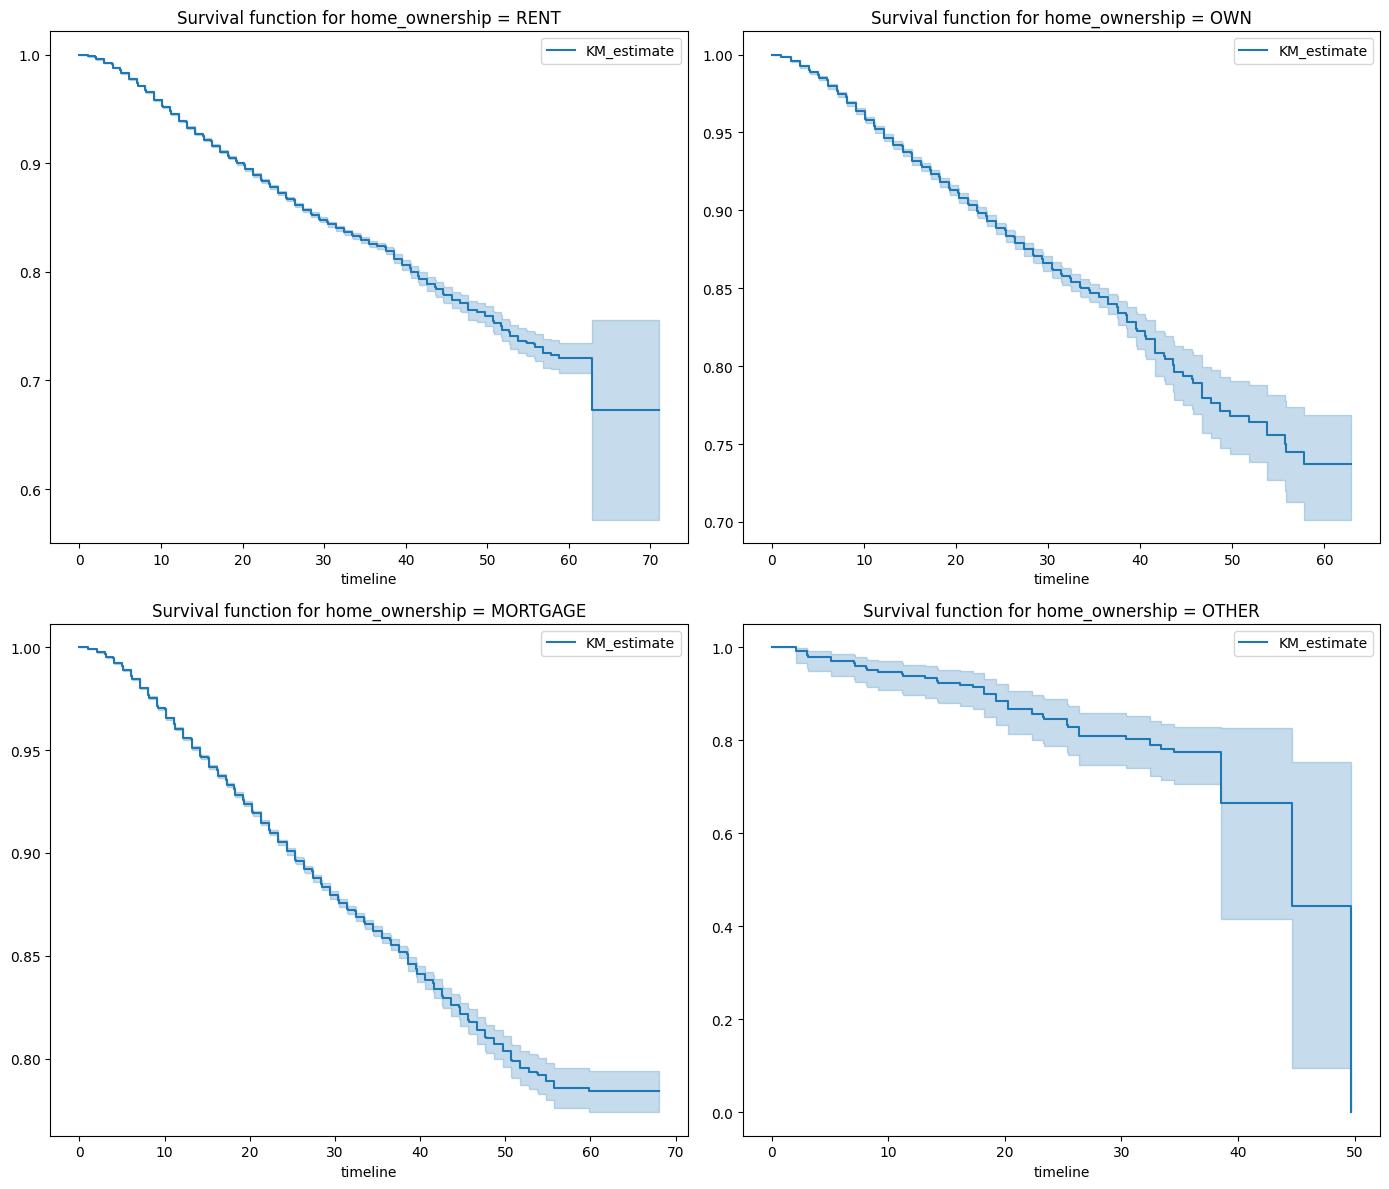

In [228]:
# Survival curves categroy - home_ownership
df.home_ownership.unique()

plt.figure(figsize=(14,12))

for i,j in enumerate(df.home_ownership.unique()):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['home_ownership'] == j],
        event_observed = df['Event'][df['home_ownership'] == j])

    plt.subplot(2,2,i+1)
    plt.title(f'Survival function for home_ownership = {j}')
    plt.xlabel('Months')
    kmf.plot_survival_function()
    plt.tight_layout()


for k1,i in enumerate(df.home_ownership.unique()):
    for k2,j in enumerate(df.home_ownership.unique()):

        if k1 <= k2:
            pass

        else:
            result = logrank_test(
                durations_A= df['Duration'][df['home_ownership'] == i],
                durations_B= df['Duration'][df['home_ownership'] == j],
                event_observed_A= df['Event'][df['home_ownership'] == i],
                event_observed_B= df['Event'][df['home_ownership'] == j]
            )
            p_val = np.round(result.p_value,4)
            if p_val <= 0.05:
                print(f'Reject H0: - There is significant difference between home_ownership- {i} and {j}')
            else:
                print('Fail to reject Ho: Both are identicals')


## Interpretation

- The Kaplan–Meier survival curves compare the survival probabilities of borrowers across different **home ownership** categories: **RENT, OWN, MORTGAGE, and OTHER**.
- Overall, borrowers with **MORTGAGE** exhibit the highest survival probability over time, indicating the lowest risk of default among the major home ownership groups.
- Borrowers who **RENT** experience a steeper decline in survival probability than those with a mortgage, suggesting a relatively higher default risk.
- The **OWN** group shows an intermediate survival pattern, lying between the MORTGAGE and RENT groups for most of the follow-up period.
- The **OTHER** category exhibits the greatest variability and the widest confidence intervals. This is likely due to the very small number of observations in this group, making its survival estimates less reliable.
- Pairwise **Log-Rank tests** indicate statistically significant differences (**p < 0.05**) between all home ownership categories.
- Therefore, the null hypothesis of identical survival distributions is rejected for every pairwise comparison.
- These findings suggest that **home ownership status is significantly associated with the time to default**, with borrowers holding a mortgage generally demonstrating better survival outcomes than those in the other categories.

> **Note:** The results for the **OTHER** category should be interpreted with caution because it contains very few observations, resulting in unstable survival estimates and wide confidence intervals.


P_val 0.0
Reject H0: - There is significant difference between verification_status- Source Verified and Verified
P_val 0.0
Reject H0: - There is significant difference between verification_status- Not Verified and Verified
P_val 0.0
Reject H0: - There is significant difference between verification_status- Not Verified and Source Verified


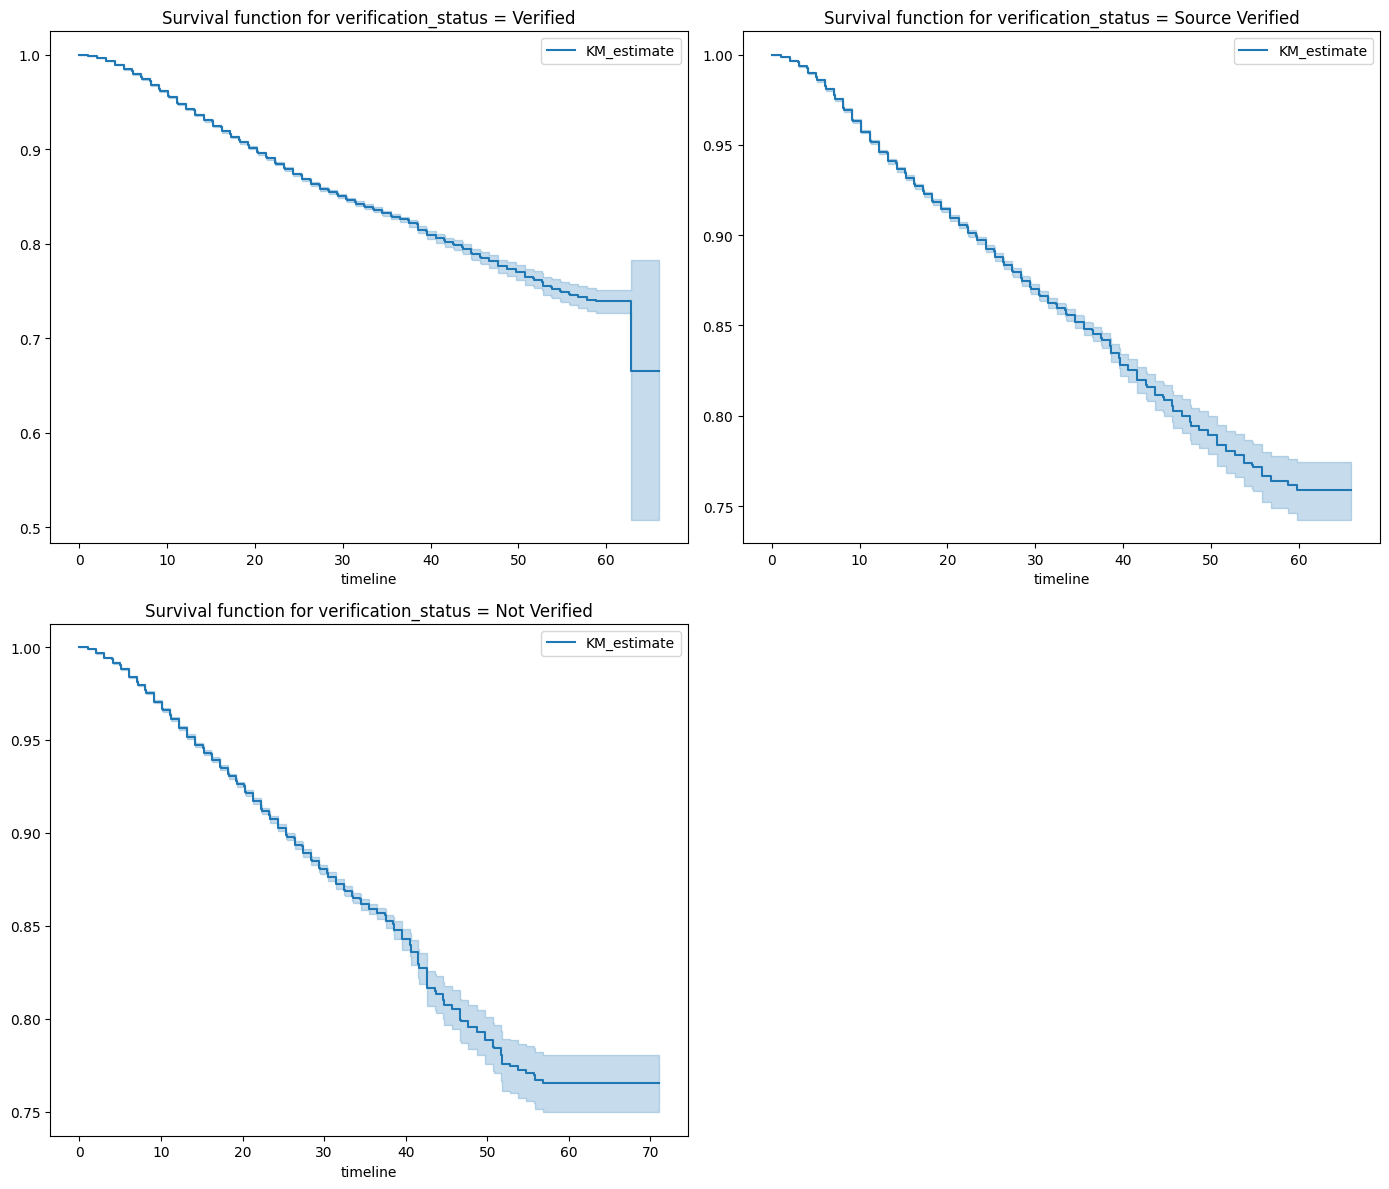

In [229]:
# Survival curves categroy - verification_status
df.verification_status.unique()

plt.figure(figsize=(14,12))

for i,j in enumerate(df.verification_status.unique()):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['verification_status'] == j],
        event_observed = df['Event'][df['verification_status'] == j])

    plt.subplot(2,2,i+1)
    plt.title(f'Survival function for verification_status = {j}')
    plt.xlabel('Months')
    kmf.plot_survival_function()
    plt.tight_layout()


for k1,i in enumerate(df.verification_status.unique()):
    for k2,j in enumerate(df.verification_status.unique()):

        if k1 <= k2:
            pass

        else:
            result = logrank_test(
                durations_A= df['Duration'][df['verification_status'] == i],
                durations_B= df['Duration'][df['verification_status'] == j],
                event_observed_A= df['Event'][df['verification_status'] == i],
                event_observed_B= df['Event'][df['verification_status'] == j]
            )
            p_val = np.round(result.p_value,4)
            if p_val <= 0.05:
                print(f'P_val {p_val}')
                print(f'Reject H0: - There is significant difference between verification_status- {i} and {j}')
            else:
                print('Fail to reject Ho: Both are identicals')


## Interpretation

- The Kaplan–Meier survival curves compare the survival probabilities of borrowers across the three **verification status** categories: **Verified**, **Source Verified**, and **Not Verified**.
- All three groups exhibit a gradual decline in survival probability over time, indicating that the likelihood of remaining event-free decreases as the loan ages.
- Borrowers in the **Source Verified** and **Not Verified** groups show slightly higher survival probabilities than those in the **Verified** group during most of the follow-up period.
- Although the differences between the survival curves appear modest, the **Log-Rank tests** indicate that these differences are statistically significant.
- Pairwise comparisons between **Verified**, **Source Verified**, and **Not Verified** all resulted in **p-values < 0.05**, leading to rejection of the null hypothesis for every comparison.
- Therefore, the survival distributions differ significantly across all verification status categories.
- These findings suggest that **verification status is significantly associated with the time to default**. However, while the differences are statistically significant, the survival curves are relatively close to one another, indicating that the practical effect may be smaller than for stronger predictors such as **loan sub-grade** or **loan term**.

P_val 0.0
Reject H0: - There is significant difference between purpose_group- Asset_Home and Debt_Management
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Business_Education and Debt_Management
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Business_Education and Asset_Home
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Personal and Debt_Management
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Personal and Asset_Home
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Personal and Business_Education
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Major_Purchase and Debt_Management
Fail to reject Ho: Both are identicals
P_val 0.0
Reject H0: - There is significant difference between purpose_group- Major_Purchase and Business_Education
P_val 0.0
Reject H0: - There is significant difference between purpose_grou

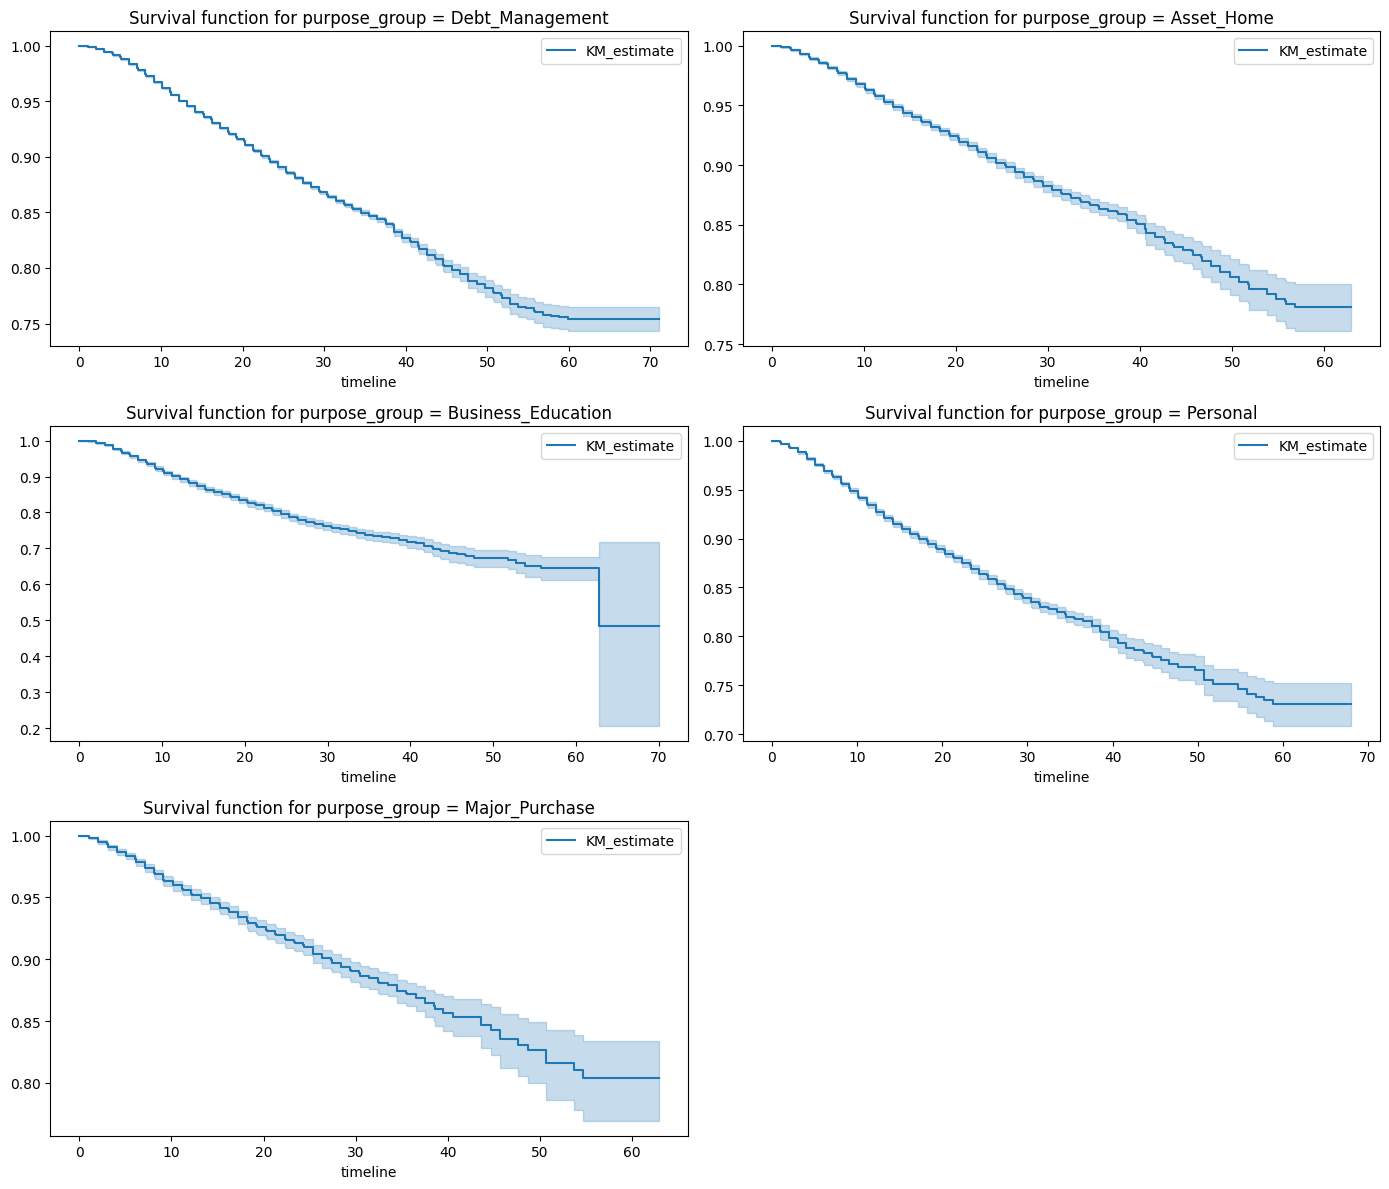

In [230]:
# Survival curves categroy - purpose_group
df.purpose_group.unique()

plt.figure(figsize=(14,12))

for i,j in enumerate(df.purpose_group.unique()):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['purpose_group'] == j],
        event_observed = df['Event'][df['purpose_group'] == j])

    plt.subplot(3,2,i+1)
    plt.title(f'Survival function for purpose_group = {j}')
    plt.xlabel('Months')
    kmf.plot_survival_function()
    plt.tight_layout()


for k1,i in enumerate(df.purpose_group.unique()):
    for k2,j in enumerate(df.purpose_group.unique()):

        if k1 <= k2:
            pass

        else:
            result = logrank_test(
                durations_A= df['Duration'][df['purpose_group'] == i],
                durations_B= df['Duration'][df['purpose_group'] == j],
                event_observed_A= df['Event'][df['purpose_group'] == i],
                event_observed_B= df['Event'][df['purpose_group'] == j]
            )
            p_val = np.round(result.p_value,4)
            if p_val <= 0.05:
                print(f'P_val {p_val}')
                print(f'Reject H0: - There is significant difference between purpose_group- {i} and {j}')
            else:
                print('Fail to reject Ho: Both are identicals')

## Interpretation

- The Kaplan–Meier survival curves compare the survival probabilities of loans across different **loan purpose groups**: **Debt Management, Asset/Home, Business/Education, Personal, and Major Purchase**.
- The survival probability decreases over time for all purpose groups, indicating that the likelihood of remaining event-free declines throughout the follow-up period.
- **Major Purchase** and **Asset/Home** loans generally exhibit higher survival probabilities, suggesting a lower risk of default compared with the other purpose groups.
- **Personal** and **Business/Education** loans display relatively lower survival probabilities, indicating a higher likelihood of experiencing the event earlier.
- The **Business/Education** group shows wider confidence intervals toward the end of the follow-up period, likely due to the smaller number of loans remaining under observation.
- Pairwise **Log-Rank tests** indicate statistically significant differences (**p < 0.05**) between almost all purpose groups.
- The only exception is the comparison between **Major Purchase** and **Asset/Home**, where the null hypothesis could **not** be rejected, suggesting that these two groups have similar survival distributions.
- These findings suggest that **loan purpose is significantly associated with the time to default**, although borrowers seeking loans for **Major Purchase** and **Asset/Home** purposes exhibit comparable survival patterns.


P_val 0.0
Reject H0: - There is significant difference between Employement - 0 and 1


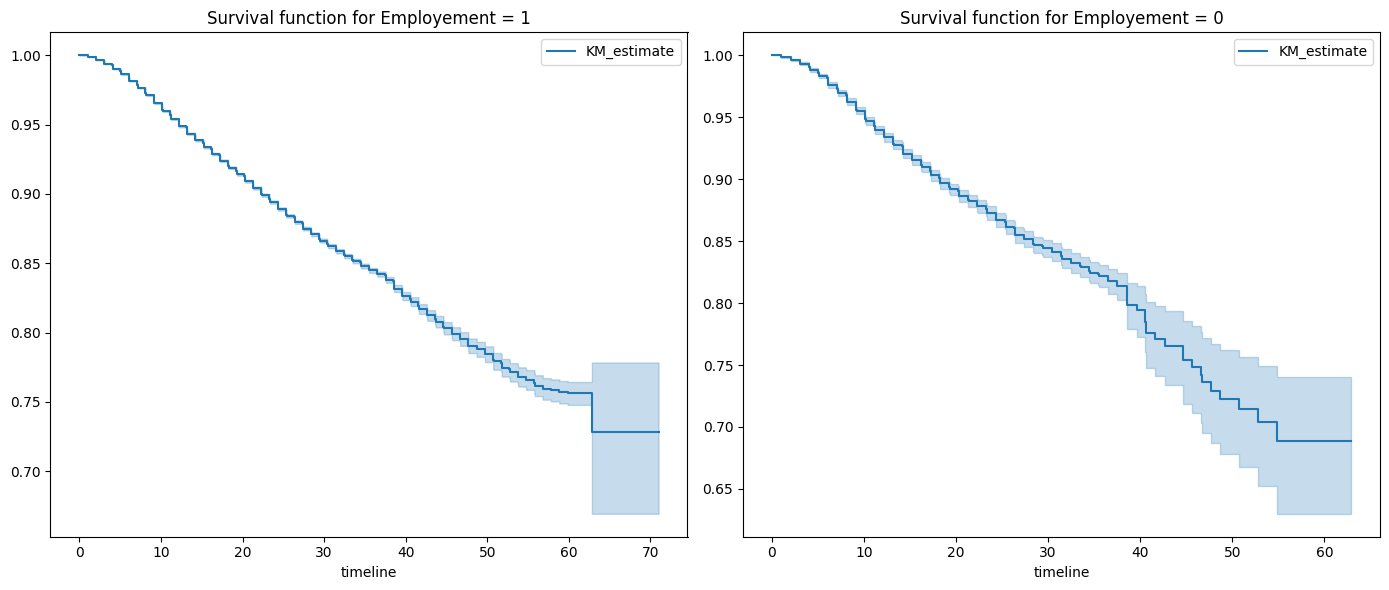

In [231]:
# Survival curves categroy - Employement
df.Employement.unique()

plt.figure(figsize=(14,6))

for i,j in enumerate(df.Employement.unique()):

    kmf= KaplanMeierFitter()
    kmf.fit(
        durations=df['Duration'][df['Employement'] == j],
        event_observed = df['Event'][df['Employement'] == j])

    plt.subplot(1,2,i+1)
    plt.title(f'Survival function for Employement = {j}')
    plt.xlabel('Months')
    kmf.plot_survival_function()
    plt.tight_layout()


for k1,i in enumerate(df.Employement.unique()):
    for k2,j in enumerate(df.Employement.unique()):

        if k1 <= k2:
            pass

        else:
            result = logrank_test(
                durations_A= df['Duration'][df['Employement'] == i],
                durations_B= df['Duration'][df['Employement'] == j],
                event_observed_A= df['Event'][df['Employement'] == i],
                event_observed_B= df['Event'][df['Employement'] == j]
            )
            p_val = np.round(result.p_value,4)
            if p_val <= 0.05:
                print(f'P_val {p_val}')
                print(f'Reject H0: - There is significant difference between Employement - {i} and {j}')
            else:
                print('Fail to reject Ho: Both are identicals')

## Interpretation

- The Kaplan–Meier survival curves compare the survival probabilities of borrowers based on **employment status**.
- Borrowers with **employment information available (Employment = 1)** maintain a consistently higher survival probability than those without employment information (**Employment = 0**) throughout the follow-up period.
- The **Employment = 0** group exhibits a steeper decline in survival probability, indicating a higher likelihood of experiencing the event (default) earlier.
- The confidence intervals widen toward the end of the observation period for both groups due to the reduced number of loans remaining under observation.
- The **Log-Rank test** produced a **p-value < 0.05**, indicating a statistically significant difference between the survival distributions of the two employment groups.
- Therefore, the null hypothesis of identical survival functions is **rejected**.
- These findings suggest that **employment status is significantly associated with the time to default**, with borrowers having recorded employment information demonstrating better survival outcomes than those without employment information.


In [232]:
df.loc[df['sub_grade'].isin(A),'sub_grade'] = 'A'
df.loc[df['sub_grade'].isin(B),'sub_grade'] = 'B'
df.loc[df['sub_grade'].isin(C),'sub_grade'] = 'C'
df.loc[df['sub_grade'].isin(D),'sub_grade'] = 'D'
df.loc[df['sub_grade'].isin(E),'sub_grade'] = 'E'
df.loc[df['sub_grade'].isin(F),'sub_grade'] = 'F'
df.loc[df['sub_grade'].isin(G),'sub_grade'] = 'G'

In [233]:
df.sub_grade.value_counts()

sub_grade
B    136803
C    125144
D     76756
A     74790
E     35669
F     13203
G      3316
Name: count, dtype: int64

In [234]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog', 'acc_now_delinq',
       'Duration', 'Event', 'Employement', 'purpose_group'],
      dtype='object')

In [235]:
df = df.drop(['acc_now_delinq' , 'revol_util'], axis = 1)      # Because more than 90% data is having no delinquency in account 

In [236]:
df.open_acc.describe(percentiles=[0.8,0.9,0.95, 0.97]) # Capping upper bound with 22 because 97% of the customers have open account less or equal 22
df.open_acc = df.open_acc.clip(0,22)

In [237]:
df['home_ownership'].value_counts()
df.loc[df['home_ownership'].isin(['OWN','OTHER']),'home_ownership'] = 'NON_MORTGAGE'



# Starting modeling of survival analysis

In [238]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Event"]           # It because data is imbalance
)

In [239]:
nominal_cols = [
    "home_ownership",
    # "verification_status",
    # "initial_list_status",
    # "purpose_group"
]
ordinal_cols = [
    "term",
    "sub_grade"
]

# Order for the 'term' variable
term_order = [
    "36 months",
    "60 months"
]

# Order for the 'sub_grade' variable

sub_grade_order = [
    'A','B','C','D','E','F','G'
]
binary_cols = [
    "Employement"
]

scale_cols = [
    "loan_amnt",
    "annual_inc",
    "revol_bal",
    "total_acc",
    "dti",
    "int_rate"
]

In [113]:
!pip uninstall scikit-learn -y
!pip install --upgrade --force-reinstall scikit-learn


Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.5.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.5.1-cp313-cp313-win_amd64.whl (12.4 MB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------- -------------------------------- 6.6/36.6 MB 32.0 MB/s eta 0:00:01
   ------------ --------------------------- 11.5/36.6 MB 32.4 MB/s eta 0:00:01
   ----------------- ---------------------- 16.3/36.6 MB 25.7 MB/s eta 0:00:01
   ------------------------- -------------- 23.1/36.6 MB 27.3 MB/s eta 0:00:01
   -------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.1 which is incompatible.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [240]:
from sklearn.preprocessing import * 
from sklearn.compose  import ColumnTransformer

oe = OrdinalEncoder(categories=[term_order,sub_grade_order])
ne = OneHotEncoder(drop='first')
sd = StandardScaler()
pt = PowerTransformer()
ct_cox = ColumnTransformer(
    transformers= [
        ('Ordinal_enc', oe ,ordinal_cols),
        ('Nominla_enc', ne, nominal_cols),
        ('Scaling', pt, scale_cols) ], 
        remainder='passthrough')

ct_cox.fit(train_df.drop(target,axis=1 ))

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordinal_enc', ...), ('Nominla_enc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [116]:
# First encoding the required columns then creating 
# another trend data where we have encoded variables plus target variables 

In [241]:
train = pd.DataFrame(data = ct_cox.transform(train_df.drop(target,axis=1 )),columns=ct_cox.get_feature_names_out())
train = pd.concat([train,df.loc[train_df.index,:][['Duration','Event']].reset_index(drop=True)], axis = 1)

In [242]:
# similarly for test set 
test = pd.DataFrame(data = ct_cox.transform(test_df.drop(target,axis=1 )),columns=ct_cox.get_feature_names_out())
test = pd.concat([test,df.loc[test_df.index,:][['Duration','Event']].reset_index(drop=True)], axis = 1)

In [243]:
train.columns

Index(['Ordinal_enc__term', 'Ordinal_enc__sub_grade',
       'Nominla_enc__home_ownership_NON_MORTGAGE',
       'Nominla_enc__home_ownership_RENT', 'Scaling__loan_amnt',
       'Scaling__annual_inc', 'Scaling__revol_bal', 'Scaling__total_acc',
       'Scaling__dti', 'Scaling__int_rate', 'remainder__verification_status',
       'remainder__delinq_2yrs', 'remainder__inq_last_6mths',
       'remainder__mths_since_last_delinq',
       'remainder__mths_since_last_record', 'remainder__open_acc',
       'remainder__pub_rec', 'remainder__initial_list_status',
       'remainder__mths_since_last_major_derog', 'remainder__Employement',
       'remainder__purpose_group', 'Duration', 'Event'],
      dtype='object')

In [120]:
# # Cox Proportional 
from lifelines import CoxPHFitter

cpm = CoxPHFitter()
cpm.fit(df = train, 
duration_col = 'Duration' , 
event_col = 'Event',
strata = ['remainder__verification_status','remainder__initial_list_status','remainder__purpose_group'])

print (f'c-index is {cpm.concordance_index_}')

c-index is 0.6701707874071802


In [121]:
cpm.score(test,scoring_method='concordance_index')

c:\Users\Dev\anaconda3\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


np.float64(0.6735468769683441)

# fitting a sample on this model and checking the model assumption

In [129]:
from sklearn.model_selection import train_test_split

train_sample = train_test_split(
    train,
    test_size=0.85,
    random_state=42,
    stratify=train["Event"]           # It because data is imbalance
)

train_sample[0].shape

(55881, 23)

In [131]:
# # Cox Proportional 
from lifelines import CoxPHFitter

cpm = CoxPHFitter()
cpm.fit(df = train_sample[0], 
duration_col = 'Duration' , 
event_col = 'Event',
strata = ['remainder__verification_status','remainder__initial_list_status','remainder__purpose_group'])

print (f'c-index is {cpm.concordance_index_}')

c-index is 0.6673819796509011


In [132]:
cpm.check_assumptions(train_sample[0]
                      ,p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Ordinal_enc__sub_grade' failed the non-proportional test: p-value is 0.0302.

   Advice 1: the functional form of the variable 'Ordinal_enc__sub_grade' might be incorrect. That
is, there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Ordinal_enc__sub_grade' using pd.cut, and then specify it in
`strata=['Ordinal_enc__sub_grade', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Scaling__loan_amnt' failed the non-proportional test: p-value is 0.0270.

   Advice 1: the functional form of the variable 'Scaling__loan_amnt' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect function

[]

# Cox Proportional Hazards Model Development

## Objective

After building the **Credit Risk Default Classification Model**, the next objective was to extend the analysis using **Survival Analysis**. While the classification model predicts **whether a borrower will default**, the Cox Proportional Hazards (CPH) model estimates **when the borrower is likely to default** by modeling the hazard (risk) of default over time.

The target variables used for survival analysis were:

- **Duration:** Number of months from loan issuance (`issue_d`) to the last payment (`last_pymnt_d`)
- **Event:** Default indicator
  - 1 = Charged Off / Default
  - 0 = Fully Paid (Right Censored)

---

# Initial Model Development

The first Cox Proportional Hazards model was developed using the processed modeling dataset generated during the classification project.

The preprocessing pipeline included:

- Missing value imputation
- One-Hot Encoding
- Ordinal Encoding
- Standard Scaling
- Feature selection from the classification model

Initially, the model was trained using the same numerical transformations that were applied in the classification pipeline.

---

# Feature Engineering Experiments

Since Cox regression is sensitive to variable distributions and proportional hazards assumptions, several feature engineering experiments were performed.

## 1. Binning Continuous Variables

Highly skewed numerical variables were converted into categorical bins to determine whether piecewise constant hazards improved model performance.

Examples included:

- Annual Income
- Loan Amount
- Revolving Balance
- DTI

The purpose was to determine whether grouping values into risk bands produced a better survival model than continuous variables.

**Observation**

No meaningful improvement in the concordance index was observed.

---

## 2. Continuous Variables without Binning

The same variables were retained in their continuous form.

This produced:

- simpler interpretation
- better numerical stability
- comparable or slightly better predictive performance

Continuous variables were therefore retained.

---

## 3. Power Transformation

Several financial variables exhibited heavy positive skewness.

To improve numerical optimization and reduce skewness, a **Power Transformer (Yeo-Johnson)** was applied.

Variables such as:

- annual_inc
- revol_bal
- loan_amnt

were transformed before fitting the Cox model.

The transformation produced more symmetric distributions while preserving variable ordering.

Performance remained largely unchanged but the optimization process became more stable.

---

## 4. Log Transformation Experiments

Logarithmic transformations were also evaluated on highly skewed variables.

Examples included:

- Revolving Balance
- Annual Income

The objective was to reduce extreme values and improve proportional hazards.

The transformed variables were compared against the Power Transformer.

The Power Transformer produced comparable or better numerical behavior and was retained.

---

# Multiple Cox Model Iterations

Rather than accepting the first Cox model, several model iterations were developed.

Each iteration involved evaluating:

- Concordance Index
- Hazard Ratios
- Statistical Significance
- Proportional Hazards Assumption
- Model Interpretability

Variables were gradually removed, regrouped or transformed based on statistical evidence.

---

# Variable Significance Assessment

Each variable's coefficient was evaluated using:

- Hazard Ratio
- Wald Test
- p-value

Variables with consistently insignificant coefficients were candidates for removal.

Example:

## Revolving Utilization

The variable

```
revol_util
```

showed little statistical significance across multiple model iterations.

Since removing it had minimal impact on model discrimination while simplifying the model, it was excluded from the final Cox model.

---

# Category Reduction

## Sub Grade

Originally,

```
A1
A2
A3
...
G5
```

resulted in approximately **35 categories**.

This produced:

- sparse observations
- unstable coefficient estimates
- proportional hazards violations

The categories were regrouped into the standard Lending Club grades:

```
A
B
C
D
E
F
G
```

Benefits:

- Reduced dimensionality
- Improved model stability
- Easier interpretation
- Eliminated PH violation for Sub Grade

---

# Feature Scaling Experiments

Several numerical variables were standardized.

Later experimentation showed that variables such as

```
open_acc
```

performed adequately without scaling.

Scaling was therefore selectively retained only where beneficial.

---

# Testing the Proportional Hazards Assumption

The fundamental assumption of the Cox model is that hazard ratios remain constant over time.

This assumption was evaluated using

```
proportional_hazard_test()
```

under two different time transformations:

- Kaplan-Meier (KM)
- Rank Transformation

Variables violating the PH assumption were identified through repeated testing after every model refinement.

---

# Addressing PH Violations

Different strategies were adopted depending on the type of variable.

## Continuous Variables

Continuous variables were evaluated using:

- transformations
- scaling
- binning
- removal (when insignificant)

---

## Categorical Variables

Categorical variables violating the PH assumption were handled using **stratification**.

The final model stratified by

- verification_status
- purpose_group
- initial_list_status

rather than estimating hazard ratios for these variables.

This allowed each stratum to have its own baseline hazard function while maintaining proportional hazards for the remaining predictors.

---

# Strata Validation

After introducing multiple stratification variables, the resulting strata sizes were examined.

Initially,

some strata contained only

- 1
- 2
- 3

observations.

Such sparse strata produce unstable baseline hazard estimates.

To improve stability,

rare home ownership categories were merged.

Example:

```
OWN
OTHER
```

↓

```
NON_MORTGAGE
```

After regrouping,

the smallest stratum contained over **100 observations**, resulting in a much more stable stratified Cox model.

---

# Final Variable Selection

The final model retained variables that were

- statistically significant
- practically meaningful
- compatible with proportional hazards
- interpretable from a business perspective

Examples include:

- loan_amnt
- annual_inc
- term
- sub_grade
- int_rate
- dti
- revol_bal
- total_acc
- delinq_2yrs
- pub_rec
- inq_last_6mths
- employment
- mths_since_last_delinq
- mths_since_last_record
- mths_since_last_major_derog
- open_acc

while

```
verification_status
purpose_group
initial_list_status
```

were modeled through stratification.

---

# Model Evaluation

The final Cox model was evaluated using the **Concordance Index (C-index)**.

The final model achieved a concordance index of approximately

```
0.67
```

This indicates that the model correctly ranks the relative default risk between two randomly selected borrowers approximately **67% of the time**, demonstrating reasonable discriminative ability for real-world credit risk data.

---

# Final Outcome

The final survival model successfully:

- Modeled **time-to-default** instead of only default occurrence.
- Handled right-censored observations.
- Evaluated proportional hazards assumptions.
- Applied statistical diagnostics for variable selection.
- Improved model stability through feature engineering.
- Reduced sparse categories through regrouping.
- Used stratification for variables violating proportional hazards.
- Produced an interpretable and statistically defensible survival model suitable for credit risk analysis.

---

# Key Learning Outcomes

This phase of the project provided practical experience with:

- Survival Analysis
- Cox Proportional Hazards Regression
- Hazard Ratios
- Right Censoring
- Time-to-Event Modeling
- Concordance Index
- Proportional Hazards Testing
- Schoenfeld Residual Diagnostics
- Stratified Cox Models
- Feature Engineering for Survival Models
- Variable Transformation
- Category Regrouping
- Statistical Model Refinement
- Credit Risk Time-to-Default Modeling

---

# Business Value

Unlike a traditional default classification model that answers:

> **"Will this borrower default?"**

the Cox Proportional Hazards model answers:

> **"When is this borrower most likely to default?"**

This additional temporal information can support:

- Dynamic credit monitoring
- Early warning systems
- Risk-based loan pricing
- Portfolio management
- Collection strategy optimization
- Expected credit loss estimation
- Loan lifecycle risk management

The survival analysis therefore complements the classification model by incorporating the timing of default, enabling more informed credit risk management decisions.

# Model Refinement Summary

The Cox Proportional Hazards model was developed through multiple iterations rather than a single model fit. The objective was not only to maximize predictive performance but also to build a statistically valid, interpretable, and stable survival model.

## Experiments Performed

During model development, the following refinements were evaluated:

- Built multiple Cox Proportional Hazards models with different feature sets.
- Compared models using both the modeling dataset and alternative feature representations.
- Evaluated continuous variables with and without binning.
- Applied Power Transformation (Yeo-Johnson) to reduce skewness in highly skewed numerical variables.
- Experimented with logarithmic transformations for financial variables.
- Assessed the impact of feature scaling on continuous predictors.
- Removed statistically insignificant variables based on coefficient significance.
- Reduced the cardinality of `sub_grade` from 35 categories to the standard 7 Lending Club grades (A–G).
- Merged sparse categorical levels (e.g., `OWN` and `OTHER` into `NON_MORTGAGE`) to improve model stability.
- Evaluated the Proportional Hazards assumption using the Schoenfeld residual test with both Kaplan-Meier and Rank time transformations.
- Addressed PH assumption violations through stratification (`verification_status`, `purpose_group`, and `initial_list_status`).
- Verified that the resulting strata contained sufficient observations for stable baseline hazard estimation.

---

# Key Observation

Despite extensive feature engineering and multiple model refinements, the model's **Concordance Index (C-index)** consistently remained within the range of approximately **0.66–0.67**, with occasional values approaching **0.68**.

The following modifications produced only marginal or no improvement in predictive performance:

- Variable transformations
- Binning of continuous variables
- Feature scaling adjustments
- Category regrouping
- Removal of insignificant predictors
- Different combinations of predictor variables
- Stratification for variables violating the proportional hazards assumption

This suggests that the model reached a point of **performance saturation**, where additional preprocessing or feature engineering improved the statistical validity and interpretability of the model but did not substantially improve its discriminative ability.

---

# Final Model Selection

The final Cox Proportional Hazards model was selected because it provides the best balance between:

- Statistical validity
- Model interpretability
- Compliance with the proportional hazards assumption
- Stable coefficient estimates
- Well-populated strata
- Competitive predictive performance (C-index ≈ 0.67)

Rather than continuing to optimize for marginal improvements in the C-index, the final model prioritizes robustness and explainability, which are essential characteristics for credit risk modeling in practical applications.

---

# Conclusion

The final survival model successfully predicts **time-to-default** while accounting for censored observations and satisfying the key assumptions of the Cox Proportional Hazards framework.

Although extensive experimentation did not produce a substantial increase in the C-index beyond approximately **0.67**, the iterative refinement process resulted in a more statistically sound, interpretable, and reliable model. This highlights an important practical lesson in predictive modeling: improvements in model quality are not measured solely by performance metrics but also by the validity, stability, and interpretability of the final model.

# Final Model

In [258]:
train

,Ordinal_enc__term,Ordinal_enc__sub_grade,Nominla_enc__home_ownership_NON_MORTGAGE,Nominla_enc__home_ownership_RENT,Scaling__loan_amnt,Scaling__annual_inc,Scaling__revol_bal,Scaling__total_acc,Scaling__dti,Scaling__int_rate,...,remainder__mths_since_last_delinq,remainder__mths_since_last_record,remainder__open_acc,remainder__pub_rec,remainder__initial_list_status,remainder__mths_since_last_major_derog,remainder__Employement,remainder__purpose_group,Duration,Event
0,1.0,2.0,0.0,0.0,0.263127,-0.440623,-0.412542,-0.320008,-0.595337,0.221139,...,0.0,0.0,4.0,0.0,f,0.0,1,Debt_Management,23.30,0.0
1,0.0,2.0,0.0,1.0,-0.378995,0.725372,-0.767134,-0.320008,-0.362322,-0.116938,...,0.0,65.0,9.0,1.0,f,0.0,1,Debt_Management,16.23,0.0
2,0.0,2.0,0.0,0.0,1.790809,0.287383,0.232812,-0.523821,0.666964,0.510972,...,0.0,0.0,7.0,0.0,f,0.0,1,Debt_Management,0.93,0.0
3,0.0,1.0,0.0,0.0,0.294296,-1.210119,-0.160009,-0.630992,-0.949255,-0.604624,...,0.0,0.0,7.0,0.0,w,0.0,1,Debt_Management,18.30,0.0
4,0.0,1.0,0.0,0.0,-1.242442,0.068536,-0.015114,-1.674169,-1.374169,-0.676159,...,0.0,0.0,6.0,0.0,f,0.0,1,Debt_Management,36.50,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372539,0.0,1.0,0.0,1.0,-0.102549,-0.882754,-0.919437,-0.857558,0.456918,-0.76422,...,0.0,0.0,9.0,0.0,f,0.0,1,Personal,36.53,0.0
372540,0.0,1.0,0.0,0.0,0.263127,0.842741,-0.357294,2.208001,-1.176106,-0.32434,...,0.0,56.0,14.0,1.0,f,0.0,1,Asset_Home,31.47,0.0
372541,0.0,2.0,0.0,1.0,-0.692111,-1.465359,-0.235962,-2.21018,-0.747097,-0.116938,...,0.0,0.0,3.0,0.0,f,0.0,1,Debt_Management,15.23,0.0
372542,1.0,4.0,0.0,0.0,1.057101,0.366559,-0.104374,0.224373,0.628112,1.353794,...,15.0,0.0,9.0,0.0,f,48.0,1,Debt_Management,13.10,0.0


In [244]:
# # Cox Proportional 
from lifelines import CoxPHFitter

cpm = CoxPHFitter()
cpm.fit(df = train, 
duration_col = 'Duration' , 
event_col = 'Event',
strata = ['remainder__verification_status','remainder__initial_list_status','remainder__purpose_group'])

print (f'c-index is {cpm.concordance_index_}')

c-index is 0.6701707874071802


In [245]:
np.round((cpm.hazard_ratios_-1)*100,2)

covariate
Ordinal_enc__term                          -11.71
Ordinal_enc__sub_grade                      -1.31
Nominla_enc__home_ownership_NON_MORTGAGE    -0.84
Nominla_enc__home_ownership_RENT            12.21
Scaling__loan_amnt                          12.01
Scaling__annual_inc                        -19.41
Scaling__revol_bal                          -5.55
Scaling__total_acc                           5.80
Scaling__dti                                 5.46
Scaling__int_rate                           70.15
remainder__delinq_2yrs                      -2.89
remainder__inq_last_6mths                   11.60
remainder__mths_since_last_delinq           -0.13
remainder__mths_since_last_record            0.12
remainder__open_acc                         -0.21
remainder__pub_rec                         -12.01
remainder__mths_since_last_major_derog      -0.16
remainder__Employement                      -8.17
Name: exp(coef), dtype: float64

In [246]:
import joblib
joblib.dump(ct_cox, 'CT_cox_model')
joblib.dump(cpm, 'cox_model')

['cox_model']

# Hazard Ratio Interpretation

The hazard ratio (HR) represents the multiplicative change in the hazard of default associated with a one-unit increase in a predictor, while holding all other variables constant.

## Variables with the Strongest Effect

| Variable | Hazard Ratio Change | Interpretation |
|----------|--------------------:|----------------|
| **int_rate** | **+70.15%** | The strongest predictor in the model. Higher interest rates substantially increase the hazard of default. |
| **annual_inc** | **−19.41%** | Higher annual income significantly reduces the hazard of default, indicating greater financial stability. |
| **home_ownership (RENT)** | **+12.21%** | Borrowers living in rented homes have a higher default hazard than the reference category. |
| **loan_amnt** | **+12.01%** | Larger loan amounts are associated with an increased hazard of default. |
| **inq_last_6mths** | **+11.60%** | More recent credit inquiries indicate higher credit-seeking activity and a higher default hazard. |
| **term** | **−11.71%** | Longer loan terms are associated with a lower hazard of default relative to the reference category. |
| **pub_rec** | **−12.01%** | Public records show a moderate reduction in hazard after accounting for the remaining predictors. |
| **Employement** | **−8.17%** | Longer employment duration is associated with lower default risk, reflecting greater financial stability. |
| **total_acc** | **+5.80%** | A higher number of total credit accounts is associated with a slight increase in default hazard. |
| **dti** | **+5.46%** | Higher debt-to-income ratios moderately increase the hazard of default. |

---

## Variables with Negligible Effect

The following variables have hazard ratios very close to **1**, indicating little or no practical effect on the timing of default after controlling for the remaining predictors:

- **sub_grade** (−1.31%)  
- **home_ownership_NON_MORTGAGE** (−0.84%)  
- **revol_bal** (−5.55%)  
- **delinq_2yrs** (−2.89%)  
- **mths_since_last_delinq** (−0.13%)  
- **mths_since_last_record** (+0.12%)  
- **open_acc** (−0.21%)  
- **mths_since_last_major_derog** (−0.16%)  

> **Observation:** These variables were retained because of their statistical or business relevance, but their estimated effect on the hazard of default is comparatively small in the final Cox Proportional Hazards model.


# ML BASED SURVIVAL MODEL 
- XGB SURVIVAL 
    - first we will encode the data and convert into a de matrix where
    - We will encode our target variable since there are two variables duration and 
    event we will use an event and encode it use in the duration Find negatively multiplying the values where the event is 0 or censored
    

In [34]:
import xgboost as xgb

In [247]:
df2 = df.copy()

In [248]:
df2.columns


Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status',
       'mths_since_last_major_derog', 'Duration', 'Event', 'Employement',
       'purpose_group'],
      dtype='object')

In [249]:
# Created another column duration encoded where all the values which has even equal 0 is encoded negatively 
df2['Duration_encoded'] = df2['Duration']
df2.loc[df['Event'] == 0 ,'Duration_encoded'] = df2['Duration_encoded'] * -1

In [250]:
nominal_cols = [
    "home_ownership",
    "verification_status",
    "initial_list_status",
    "purpose_group"
]
ordinal_cols = [
    "term",
    "sub_grade"
]

# Order for the 'term' variable
term_order = [
    "36 months",
    "60 months"
]

# Order for the 'sub_grade' variable

sub_grade_order = [
    'A','B','C','D','E','F','G'
]
binary_cols = [
    "Employement"
]

scale_cols = [
    "loan_amnt",
    "annual_inc",
    "revol_bal",
    "total_acc",
    "dti",
    "int_rate"
]

In [251]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    df2.drop(['Duration_encoded'], axis =1 ),
    df2['Duration_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df2["Event"]   
    )


In [161]:
y_train.sample()

459910   -24.33
Name: Duration_encoded, dtype: float64

In [252]:
from sklearn.preprocessing import * 
from sklearn.compose  import ColumnTransformer

oe = OrdinalEncoder(categories=[term_order,sub_grade_order])
ne = OneHotEncoder(drop='first')
sd = StandardScaler()
pt = PowerTransformer()
ct_xgb = ColumnTransformer(
    transformers= [
        ('Ordinal_enc', oe ,ordinal_cols),
        ('Nominla_enc', ne, nominal_cols)
        ], 
        remainder='passthrough')


In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgb_model = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    random_state=42, 
    n_jobs = - 1
)

pipe = Pipeline(steps=[('ct',ct_xgb),
                       ('model',xgb_model)])


In [165]:
# Making a scorer for C index Because the default scorer is R2
from lifelines.utils import concordance_index
from sklearn.metrics import make_scorer

def cindex_scorer(estimator, X, y):
    
    # Risk scores
    risk = estimator.predict(X)

    # Recover Duration and Event
    duration = abs(y)
    event = (y > 0)

    return concordance_index(
        event_times=duration,
        predicted_scores=-risk,
        event_observed=event
    )

In [171]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7,12,15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5, 10],
    "model__gamma": [0, 0.1, 0.3]
}

rcv = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring=cindex_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=2    #Prints messages for each fold of cross-validation for every candidate parameter set.
)

In [172]:
rcv.fit(X_train.drop(['Duration','Event'], axis =1 ),y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function cin...0021747C47600>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, 

In [174]:

print(rcv.best_score_)
print(rcv.best_params_)

0.6826831207017384
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 1.0}


### Hyperparameter Tuning

Randomized Search Cross-Validation was performed to optimize the XGBoost Survival model. A total of **20 random hyperparameter combinations** were evaluated using **3-fold cross-validation**, with the **Concordance Index (C-index)** as the optimization metric. The best-performing model achieved a **cross-validated C-index of 0.6827**, using **200 estimators**, a **maximum tree depth of 5**, a **learning rate of 0.05**, **full row and column sampling (1.0)**, **minimum child weight of 1**, and **gamma of 0**.

In [179]:
# Applying a critical
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200,300,500],
    "model__max_depth": [4,5,6],
    "model__learning_rate": [0.05],
    "model__subsample": [1.0],
    "model__colsample_bytree": [1.0],
    "model__min_child_weight": [0.8,0.9,1],
    "model__gamma": [0]
}

gcv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    scoring=cindex_scorer,
    n_jobs=-1,
    verbose=2    #Prints messages for each fold of cross-validation for every candidate parameter set.
)

In [180]:
gcv.fit(X_train.drop(['Duration','Event'], axis =1 ),y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [1.0], 'model__gamma': [0], 'model__learning_rate': [0.05], 'model__max_depth': [4, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function cin...0021747C47600>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.

In [181]:
gcv.best_score_

np.float64(0.6832486968956957)

### Fine-Tuning the XGBoost Model

Based on the results obtained from Randomized Search, a focused Grid Search was conducted around the best-performing hyperparameter values. This exhaustive search explored a smaller parameter space to further refine the model. The optimized model achieved a **best cross-validated Concordance Index (C-index) of 0.6832**, representing a marginal improvement over the Randomized Search result and indicating that the model performance had largely converged.

In [182]:
gcv.best_params_

{'model__colsample_bytree': 1.0,
 'model__gamma': 0,
 'model__learning_rate': 0.05,
 'model__max_depth': 4,
 'model__min_child_weight': 0.9,
 'model__n_estimators': 300,
 'model__subsample': 1.0}

# Final ML MODEL

In [253]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=0.9,
    gamma=0,
    random_state=42,
    n_jobs=-1
)

In [254]:
pipe = Pipeline([
    ("Transformation", ct_xgb),
    ("model", xgb_model)
])

pipe.fit(X_train.drop(['Duration','Event'], axis =1 ), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Transformation', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['loan_amnt','term','int_rate',...,'mths_since_last_major_derog', 'Employement','purpose_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Ordinal_enc', ...), ('Nominla_enc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

In [255]:
from lifelines.utils import concordance_index

c_index = concordance_index(
    event_times=X_train["Duration"],
    predicted_scores=-pipe.predict(X_train.drop(['Duration','Event'], axis =1 )),
    event_observed=X_train["Event"]
)

print(c_index)


c_index = concordance_index(
    event_times=X_test["Duration"],
    predicted_scores=-pipe.predict(X_test.drop(['Duration','Event'], axis =1 )),
    event_observed=X_test["Event"]
)

print(c_index)

0.6971369411962883
0.6835946012538661


In [256]:
import joblib
joblib.dump(ct_xgb, 'CT_xgb_model')
joblib.dump(pipe, 'xgb_pipeline')
joblib.dump(xgb_model, 'xgb_model')

['xgb_model']

In [257]:
df.to_csv('Data_for_cox_model.csv')
df2.to_csv('Data_for_xgb_model.csv')

### Final Model Evaluation

The optimized XGBoost Survival model was trained using the best hyperparameters obtained from Grid Search and evaluated using the **Concordance Index (C-index)**. The model achieved a **training C-index of 0.6971** and a **testing C-index of 0.6836**, indicating good generalization with only a small reduction in performance on unseen data. The close agreement between the training and testing scores suggests that the model does not exhibit significant overfitting and provides stable predictive performance for survival-based credit risk assessment.

# Survival Analysis Summary

The objective of this phase was to extend the credit risk analysis beyond binary default prediction by incorporating **time-to-default information** using survival analysis techniques. Two survival models were investigated: the **Cox Proportional Hazards (Cox PH) model** and the **XGBoost Survival model**. The entire workflow involved extensive data preprocessing, assumption validation, feature engineering, model development, hyperparameter optimization, and final model evaluation.

---

## 1. Data Preparation

The modelling dataset obtained from the previous phase of the project was used as the input for survival analysis. The target variables consisted of:

- **Duration** – Time until loan default or censoring.
- **Event** – Event indicator, where:
  - `1` = Default occurred.
  - `0` = Loan was censored (did not default during the observation period).

The dataset was divided into training and testing sets using **stratified sampling** to preserve the proportion of default and non-default observations.

---

## 2. Feature Engineering

Several preprocessing strategies were explored to improve model performance and satisfy the assumptions of the Cox model.

The following experiments were conducted:

- Ordinal encoding of ordered categorical variables.
- One-hot encoding of nominal categorical variables.
- Standardization of continuous variables.
- Binning of continuous variables into ordinal groups.
- Modifying the functional form of variables.
- Power and logarithmic transformations for skewed predictors.
- Comparing models with and without feature binning.

Different combinations of engineered features were evaluated to determine their impact on predictive performance.

---

## 3. Cox Proportional Hazards Model

The Cox Proportional Hazards model was selected as the primary statistical survival model because it estimates the relationship between predictor variables and the hazard of default while maintaining interpretability through hazard ratios.

The model was trained using the processed feature set and evaluated using the **Concordance Index (C-index)**.

---

## 4. Cross Validation

To assess the stability of the Cox model, repeated train-test validation was performed.

The average Concordance Index consistently remained around:

- **0.67 – 0.68**

indicating stable predictive performance across multiple data splits.

---

## 5. Assumption Checking

The proportional hazards assumption was evaluated using the **Schoenfeld residual test** provided by the Lifelines library.

Several predictors violated the proportional hazards assumption, including:

- Sub Grade
- Purpose Group
- Verification Status
- Home Ownership
- Annual Income
- DTI
- Interest Rate
- Revolving Utilization
- Open Accounts

Each violation was investigated individually.

---

## 6. Model Refinement

Multiple approaches were explored to satisfy the proportional hazards assumption.

These included:

- Binning continuous predictors.
- Regrouping ordinal categories.
- Removing variables with negligible predictive contribution.
- Changing functional forms.
- Applying logarithmic and power transformations.
- Introducing stratification for categorical variables violating the PH assumption.

Several alternative Cox models were trained after each modification.

---

## 7. Stratification

For categorical predictors exhibiting non-proportional hazards, stratification was introduced.

The final model stratified the baseline hazard according to:

- Purpose Group
- Verification Status
- Initial List Status

This allowed separate baseline hazard functions to be estimated for each stratum while maintaining common regression coefficients across strata.

---

## 8. Final Cox Model

After multiple iterations of feature engineering and assumption checking, the final Cox model demonstrated:

- Improved satisfaction of proportional hazards assumptions.
- Stable model coefficients.
- Meaningful hazard ratio interpretation.
- Concordance Index consistently around **0.68**.

The model also provided:

- Hazard Ratios
- Confidence Intervals
- Baseline Hazard Function
- Baseline Survival Function
- Partial Effect Plots

making it highly interpretable for credit risk analysis.

---

## 9. Random Survival Forest (Exploratory)

Random Survival Forest was initially implemented to investigate whether a nonlinear ensemble-based survival model could improve predictive performance.

Several models with different tree depths and numbers of estimators were trained.

Although the model achieved a Concordance Index comparable to the Cox model, hyperparameter tuning proved computationally expensive for the available dataset (approximately 200,000 observations). Consequently, Random Survival Forest was excluded from the final comparative analysis in favour of a more computationally efficient machine learning model.

---

## 10. XGBoost Survival Model

To capture nonlinear relationships without requiring the proportional hazards assumption, the XGBoost Survival model with the **Cox survival objective** was implemented.

Unlike the Cox model, XGBoost required the survival target to be encoded as:

- Positive survival time → Event occurred.
- Negative survival time → Right censored.

The model was integrated into a Scikit-learn Pipeline, allowing preprocessing and model training to be performed simultaneously.

---

## 11. Hyperparameter Optimization

Model performance was optimized using two successive tuning strategies.

### Randomized Search

A Randomized Search Cross-Validation procedure evaluated:

- 20 random hyperparameter combinations.
- 3-fold cross-validation.
- Concordance Index as the optimization metric.

The best cross-validated performance achieved:

- **C-index = 0.6827**

---

### Grid Search

A focused Grid Search was subsequently performed around the best parameter region identified by the Randomized Search.

The optimized model achieved:

- **Best Cross-Validated C-index = 0.6832**

The optimal configuration consisted of:

- 300 estimators
- Maximum depth = 4
- Learning rate = 0.05
- Minimum child weight = 0.9
- Subsample = 1.0
- Column sample by tree = 1.0
- Gamma = 0

---

## 12. Final XGBoost Model Evaluation

The optimized XGBoost Survival model was trained using the selected hyperparameters.

Model performance was evaluated using the Concordance Index.

Final performance:

| Dataset | Concordance Index |
|----------|------------------:|
| Training | **0.6971** |
| Testing | **0.6836** |

The small difference between training and testing performance indicates good generalization with no significant evidence of overfitting.

---

## 13. Key Observations

Throughout the survival modelling process, numerous preprocessing strategies and modelling approaches were explored.

These included:

- Feature binning.
- Functional form modifications.
- Logarithmic transformations.
- Power transformations.
- Variable regrouping.
- Stratification.
- Hyperparameter optimization.

Despite these extensive modifications, the predictive performance remained remarkably stable.

Both the Cox Proportional Hazards model and the XGBoost Survival model consistently achieved a **Concordance Index between approximately 0.68 and 0.69**, suggesting that the predictive capability is primarily constrained by the information contained within the available predictors rather than by the modelling technique itself.

---

## 14. Final Conclusion

Two fundamentally different survival modelling approaches were successfully implemented and evaluated.

The **Cox Proportional Hazards model** provides excellent interpretability through hazard ratios, statistical significance testing, and baseline survival estimation, making it well suited for understanding the factors influencing default risk.

The **XGBoost Survival model** offers greater modelling flexibility by capturing nonlinear relationships and interactions without requiring the proportional hazards assumption. Hyperparameter optimization resulted in a slight improvement in predictive performance compared to the Cox model.

Overall, both models demonstrated similar predictive capability, with XGBoost achieving a marginally higher Concordance Index. The final stage of the study focuses on interpreting these models through **SHAP-based feature explanations for XGBoost** and a comparative analysis against the statistically interpretable Cox Proportional Hazards model to evaluate their practical applicability in credit risk analytics.